In [1]:
import numpy as np, itertools
import tools21cm as t2c
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

from scipy import special
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import jn
from scipy.special import jv
from scipy.integrate import quad

from tqdm import tqdm
from ipywidgets import interact

import astropy.units as u
import astropy.constants as cst
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import Angle

from matplotlib.colors import LogNorm

In [5]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    Simulated synchrotron emission. Simplified because of removed noise.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        C_syn = A150*(1000/l_cb)**beta_
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
    
    return gf_data.squeeze(), l_cb

def telescope_beam_pattern(x, y, D=45, z=7):
    """
    Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))

def gaussian_source_2d(x, y, cov):
    """
    Covariance matrix takes two values which provided in arcseconds.
    """
    mean= np.array([0, 0]) #Mean
    #Covariance matrix:
    cov= np.array([[(cov[0]*u.arcsec).to('rad').value, 0], [0, (cov[1]*u.arcsec).to('rad').value]])
    
    x_diff = x- mean[0]
    y_diff = y- mean[1]
    
    inv_cov = np.linalg.inv(cov)

    exponent = -0.5 * (x_diff**2 *inv_cov[0,0] + y_diff**2 *inv_cov[1,1] + 2*x_diff*y_diff*inv_cov[0,1])
    prefactor = 1 / (2*np.pi*np.sqrt(np.linalg.det(cov)))

    return prefactor * np.exp(exponent)

def hirax_layout(N_ant, range):
    """
    Generates a square grid layout of antennas, similar to HIRAX.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).

    Returns
    -------
    ndarray
        An array containing the coordinates of the antennas arranged in a square grid.
        Each row represents the (x, y) coordinates of an antenna.
    """
    x= np.linspace(range[0], range[1], int(np.sqrt(N_ant)))
    X, Y= np.meshgrid(x, x)
    return np.dstack((X, Y)).reshape(-1, 2)

def random_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.uniform(range[0], range[1], N_ant)
    Y= np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def median_index(list):
    """
    Returns the index of the median value in a numpy list.

    Parameters:
    - list: numpy array or list
        The input array containing numerical values.

    Returns:
    - int
        The index of the element closest to the median value.

    Raises:
    - ValueError: If the input list is empty.
    """
    average = np.mean(list)
    closest_index = np.abs(list - average).argmin()
    return closest_index

def arbitrary_index(list, value):
    closest_index = np.abs(list - value).argmin()
    return closest_index

def visibility_matrix_func(xyz_coord, lmn_coord, redshift, I_sky, beam_pattern):
    """
    Compute the visibility matrix for a given set of antennas and sky image.

    Parameters
    ----------
    xyz_coord : array_like
        Array of x, y, and z coordinates of antennas.
    lmn_coord : array_like
        Array of l, m, and n coordinates representing the direction of the sky image.
    redshift : float
        Redshift observed with 21-cm.
    I_sky : array_like
        Array containing the intensity of the sky image.
    beam_pattern : array_like
        Array representing the beam pattern of the telescope.

    Returns
    -------
    visibility_list : ndarray
        A 1D array of length N_B containing visibility values for each baseline.
    visibility_matrix : ndarray
        A 2D array representing the visibility matrix with shape (N_ant, N_ant).
    """
    N_ant= len(xyz_coord) #Number of antennas
    N_B= int(N_ant*(N_ant-1) / 2) #Number of baselines

    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c / freq

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas

    baseline_coord= np.empty((N_B, xyz_coord.shape[1])) #Initialize a baseline vectors array
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]

        #Calculate distance between antennas
        uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
        baseline_coord[i]= uv

        #Calculate the fringe pattern
        fringe= np.exp(-2j * np.pi * (uv[0].value * lmn_coord[:,0] + uv[1].value * lmn_coord[:,1]))

        #Reshape fringe_pattern to match the shape of I_sky
        fringe_reshaped = fringe.reshape(I_sky.shape)

        #Calculate visibility for the current baseline
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)

        visibility_list[i]= visibility

        #Store the visibility value in the array
        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility) #Visibility is symmetric

    return visibility_list, visibility_matrix, baseline_coord

def visibility_rotation_synthesis(lmn_coord, rotated_baselines, I_sky, beam_pattern, N_ant):
    N_B= int(N_ant*(N_ant-1) / 2)

    assert np.shape(rotated_baselines)[0] == N_B

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= rotated_baselines[i]
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))
        fringe_reshaped = fringe.reshape(I_sky.shape)
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)
        visibility_list[i]= visibility

        visibility_matrix[aa, bb]=visibility
        visibility_matrix[bb, aa] = np.conj(visibility)

    return visibility_list, visibility_matrix

def Earth_Rotation_Effect(HA, delta):
    HA, delta = HA.to('rad').value, delta.to('rad').value
    
    return np.array([[np.sin(HA), np.cos(HA)], 
                     [-np.sin(delta)*np.cos(HA), np.sin(delta)*np.sin(HA)]])

def visibility_correlation_func(index, baseline_coord, visibility_list, N_B):
    """
    Computes visibility correlation and baseline distances from a given baseline index.

    Parameters:
    - index: int
        Index of the baseline vector.
    - baseline_coord: numpy.ndarray
        Array containing baseline coordinates.
    - visibility_list: numpy.ndarray
        Array containing visibility values.
    - N_B: int
        Total number of baseline vectors.

    Returns:
    - vis_corr: numpy.ndarray
        Array of visibility correlations.
    - baseline_distances_norm: numpy.ndarray
        Array of normalized baseline distances.
    """
    indices= np.linspace(0, N_B-1, N_B)
    indices_combinations= list(itertools.product([index], range(N_B))) #Generate combinations
    baseline_distances= np.empty((len(indices), 2)) #Create empty array for calculating distance between two vectors
    vis_corr= np.empty(len(indices), dtype=np.complex128)

    for i in range(len(indices)):
        ii, jj = indices_combinations[i]
        vis_corr[i]= visibility_list[ii] * np.conj(visibility_list[jj])
        baseline_distances[i]= baseline_coord[jj] - baseline_coord[ii]

    baseline_distances_norm= np.linalg.norm(baseline_distances, axis=1)

    return vis_corr.real, baseline_distances_norm

def uv_space(layout, redshift):
    N_ant=len(layout)
    N_B= int(N_ant*(N_ant-1) / 2)
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, layout.shape[1]))
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= ((layout[bb]- layout[aa]) / lam)
        baseline_coord[i]= uv

    return baseline_coord

def nearest_neighbour_func(freqx, freqy, baselines):
    """
    Finds the nearest neighbors of the given baselines in the frequency domain.

    Parameters:
    - freqx (array-like): Array of x-coordinates of the frequency grid.
    - freqy (array-like): Array of y-coordinates of the frequency grid.
    - baselines (array-like): Array of baseline coordinates.

    Returns:
    - uv_points (ndarray): Array of all frequency grid points.
    - distances (ndarray): Array of distances between baselines and their nearest neighbors.
    - indices (ndarray): Array of indices of the nearest neighbors in the frequency grid.
    """
    u_freq, v_freq= np.meshgrid(freqx, freqy)
    uv_points = np.dstack((u_freq, v_freq)).reshape(-1, 2)
    tree = cKDTree(uv_points)
    distances, indices = tree.query(baselines)

    return uv_points, distances, indices

def indices_reshape(indices, square_size):
    """
    Reshapes a 1D array of indices into a 2D array of indices based on a given square size.

    Parameters:
    indices (numpy.ndarray): 1D array of indices.
    square_size (int): Size of the square grid.

    Returns:
    numpy.ndarray: 2D array of indices.
    """
    array= np.zeros(square_size**2)
    array[indices]= 1
    mask_2d= array.reshape(square_size, square_size)
    indices_2d= np.argwhere(mask_2d==1)

    return indices_2d, mask_2d

def interpolation_func(freq_x, freq_y, image_array, baselines):
    """
    Interpolates the given image array using the provided frequency values and baselines.

    Parameters:
    freq_x (array-like): The x-axis frequency values.
    freq_y (array-like): The y-axis frequency values.
    image_array (array-like): The 2D array representing the image.
    baselines (array-like): The baselines for which interpolation is performed.

    Returns:
    array-like: The interpolated values corresponding to the given baselines.
    """
    spline = RectBivariateSpline(freq_x, freq_y, image_array)
    interp_values = spline.ev(baselines[:, 0], baselines[:, 1])

    return interp_values

def visibility_matrix_func_new_method(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    l_coord, m_coord= np.meshgrid(sky_coord, sky_coord)
    N_ant= len(xyz_coord)
    N_B= int(N_ant*(N_ant-1) / 2)
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
    visibility_list= np.empty(N_B, dtype=np.complex128)

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]
        uv= (xyz_coord[bb]- xyz_coord[aa]) / lam
        baseline_coord[i]= uv
        fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis= np.sum(fringe*I_sky*beam_pattern)
        visibility_list[i]= vis
        visibility_matrix[aa, bb]= vis
        visibility_matrix[bb, aa]= np.conj(vis)
    
    return visibility_list, visibility_matrix, baseline_coord

def image_reconstructing_func(vis_list, baselines, u_min, u_max, bin_len, bin_res):
    """
    Reconstructs an image from visibility data using interferometry.

    Parameters:
    vis_list (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    u_min (float): Minimum value of the u-coordinate.
    u_max (float): Maximum value of the u-coordinate.
    bin_len (float): Length of the bin.
    bin_res (float): Resolution of the bin.

    Returns:
    array-like: Reconstructed image.
    """
    uv_bin= np.linspace(u_min, u_max, int(bin_len/ bin_res))
    
    uv_plane_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='sum', bins=[uv_bin, uv_bin]).statistic
    uv_sampl_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='count', bins=[uv_bin, uv_bin]).statistic
    uv_plane_binned /= np.where(uv_sampl_binned > 0, uv_sampl_binned, 1)

    x= np.fft.fftshift(np.fft.fftfreq(len(uv_bin), np.diff(uv_bin)[0]))

    return uv_plane_binned, uv_bin, uv_sampl_binned, x

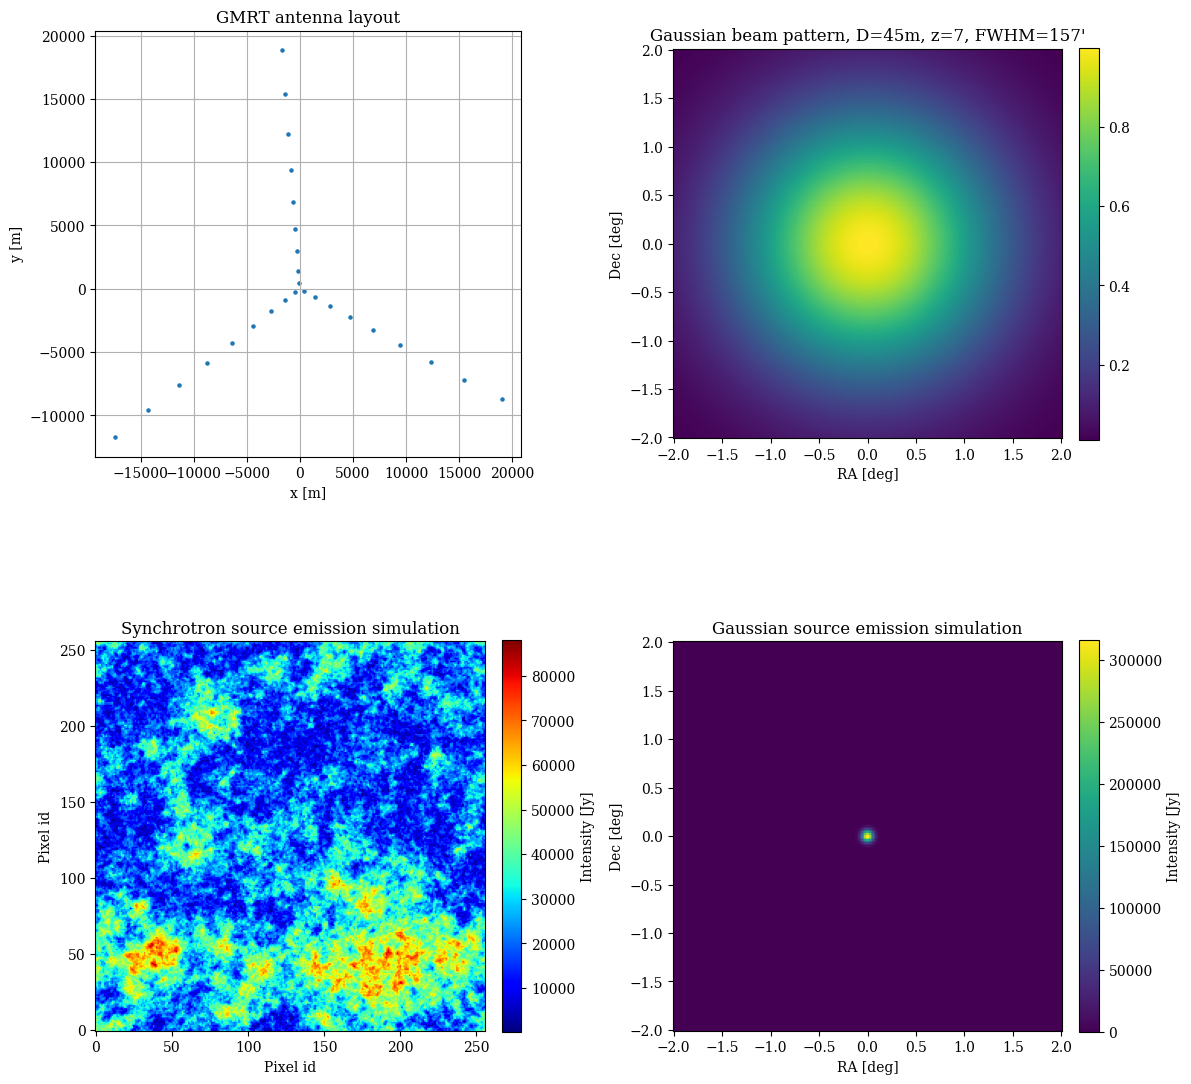

In [4]:
FoV= 4*u.deg

thet= np.linspace(-FoV/2, FoV/2, 256).to('rad').value
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
ang_dim_dist= FoV.to('rad').value * cosmo.angular_diameter_distance(rshift).value 

#***********************************************
vla_layout = np.loadtxt('vla_layout.txt')
#Remove the z-coordinates from the layout:
#vla_layout= vla_layout[:,:-1]
#***********************************************

#Gaussian and synchrotron sources, beam pattern
gaussian_source= gaussian_source_2d(l_coord, m_coord, [0.1, 0.1])
synchro_source, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=ang_dim_dist, rseed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord)

#Plotting the sources and the layout
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0,0].scatter(vla_layout[:,0], vla_layout[:,1], s=5, color='tab:blue')
axes[0,0].set_title("GMRT antenna layout")
axes[0,0].set_ylabel('y [m]')
axes[0,0].set_xlabel('x [m]')
axes[0,0].set_box_aspect(1)
axes[0,0].grid()

im0 = axes[0,1].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axes[0,1].set_ylabel('Dec [deg]')
axes[0,1].set_xlabel('RA [deg]')
axes[0,1].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
axes[0,1].set_box_aspect(1)
plt.colorbar(im0, fraction=0.046, pad=0.04)

im1 = axes[1,0].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[1,0].set_title("Synchrotron source emission simulation")
axes[1,0].set_ylabel('Pixel id')
axes[1,0].set_xlabel('Pixel id')
axes[1,0].set_box_aspect(1)
plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)

im2 = axes[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axes[1,1].set_title('Gaussian source emission simulation')
axes[1,1].set_ylabel('Dec [deg]')
axes[1,1].set_xlabel('RA [deg]')
axes[1,1].set_box_aspect(1)
plt.colorbar(im2, label='Intensity [Jy]', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

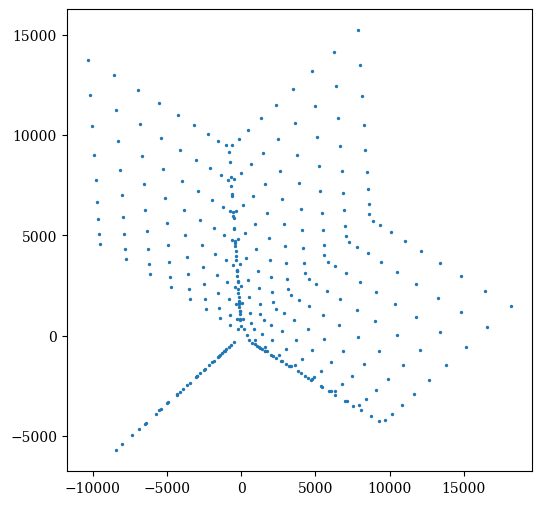

In [8]:
baseline_coords= uv_space(vla_layout, rshift)

fig, axs= plt.subplots(1, 1, figsize=(6, 6))
axs.scatter(baseline_coords[:,0], baseline_coords[:,1], s=2, color='tab:blue')

In [14]:
print(len(vla_layout))

27


In [27]:
N_ant= len(vla_layout)
N_B= int(N_ant*(N_ant-1) / 2)
pair_comb= list(itertools.combinations(range(N_ant), 2))
baseline_coord_pos= np.empty((2*N_B, vla_layout.shape[1]))
baseline_coord_neg= np.empty((2*N_B, vla_layout.shape[1]))
freq = t2c.cosmo.z_to_nu(rshift) * 10**6
lam = cst.c.value / freq

for i in range(N_B):
    aa, bb= pair_comb[i]
    uv= ((vla_layout[bb]- vla_layout[aa]) / lam)
    baseline_coord_pos[i]= uv
    baseline_coord_neg[i]= -uv

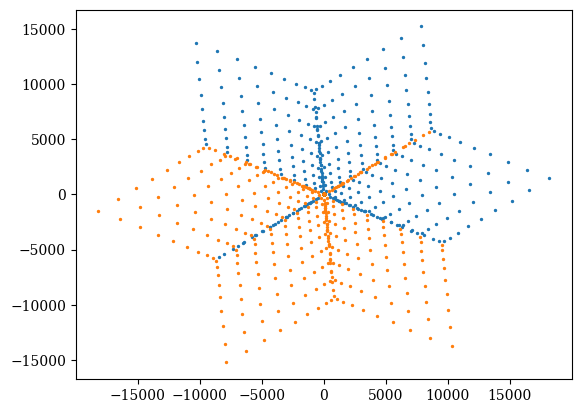

In [30]:
plt.scatter(baseline_coord_pos[:,0], baseline_coord_pos[:,1], s=2)
plt.scatter(baseline_coord_neg[:,0], baseline_coord_neg[:,1], s=2)

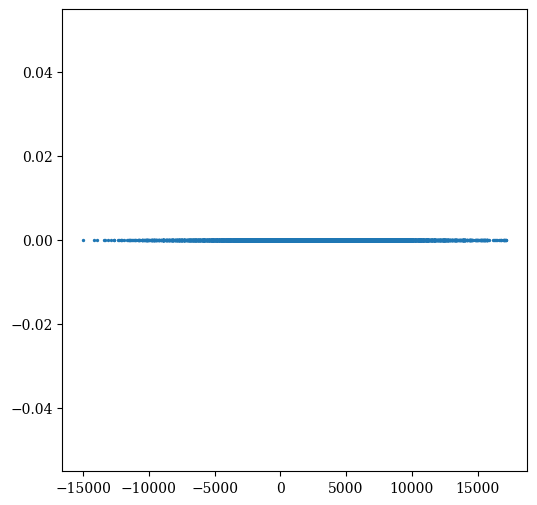

In [43]:
fig, axs= plt.subplots(1, 1, figsize=(6, 6))

dec= 0.*u.deg
h_angle= np.linspace(-4, +4, 24) * u.hourangle

for i_t, h in enumerate(h_angle):
    rotmx= Earth_Rotation_Effect(HA=h, delta=dec)
    baseline_rot_pos= np.dot(rotmx, baseline_coord_pos.T).T
    baseline_rot_neg= np.dot(rotmx, baseline_coord_neg.T).T

    axs.scatter(baseline_rot_pos[:,0], baseline_rot_pos[:,1], s=2, color='tab:blue')
    #axs.scatter(baseline_rot_neg[:,0], baseline_rot_neg[:,1], s=2, color='tab:red')